In [12]:
!pip install open_clip_torch

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import numpy as np
import random
import os
import shutil
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, confusion_matrix)
from statsmodels.stats.contingency_tables import mcnemar
import open_clip
import hashlib
from IPython.display import Image as IPImage, display

In [14]:
def save_and_display(fig, filename, dpi=200):
    filepath = f"/kaggle/working/{filename}"
    fig.savefig(filepath, dpi=dpi, bbox_inches='tight')
    plt.close(fig)
    display(IPImage(filename=filepath, width=800))
    print(f" ✓ Saved: {filepath}")
    return filepath

In [15]:
# ========================= CONFIG =========================
IMAGE_SIZE = 224
N_WAY = 4
SHOTS = [1, 5, 10]
EPISODES_EVAL = 600

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
CI_ALPHA = 0.05
BOOTSTRAP_N = 1000

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


CLASS_NAMES = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

print(f"Few-Shot | Device: {DEVICE}")
print(f"Episodes: {EPISODES_EVAL} | CI: {int((1-CI_ALPHA)*100)}%\n")

Few-Shot | Device: cuda
Episodes: 600 | CI: 95%



In [16]:
# ========================= DATASET =========================
DATASET_PATH = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri"
TRAIN_DIR = os.path.join(DATASET_PATH, "Training")
TEST_DIR  = os.path.join(DATASET_PATH, "Testing")

print("Using Dataset:", DATASET_PATH)

Using Dataset: /kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri


In [17]:
# ========================= LOAD DATA =========================
def load_classwise_split(root):
    classwise = {i: [] for i in range(N_WAY)}
    print(f"\n Loading split from: {root}")
    
    for i, cls in enumerate(CLASS_NAMES):
        cls_dir = os.path.join(root, cls)
        if os.path.exists(cls_dir):
            paths = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            classwise[i] = paths
            print(f"  {cls:18} → {len(paths)} images")
        else:
            print(f" Missing folder: {cls_dir}")
    return classwise

support_pool = load_classwise_split(TRAIN_DIR)
query_pool   = load_classwise_split(TEST_DIR)

print("\nFinal Dataset Distribution:")
print("Support:", [len(support_pool[i]) for i in range(N_WAY)])
print("Query  :", [len(query_pool[i]) for i in range(N_WAY)])

if sum(len(v) for v in support_pool.values()) == 0:
    raise ValueError("No images loaded! Check dataset path or folder names.")


 Loading split from: /kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training
  glioma_tumor       → 826 images
  meningioma_tumor   → 822 images
  no_tumor           → 395 images
  pituitary_tumor    → 827 images

 Loading split from: /kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing
  glioma_tumor       → 100 images
  meningioma_tumor   → 115 images
  no_tumor           → 105 images
  pituitary_tumor    → 74 images

Final Dataset Distribution:
Support: [826, 822, 395, 827]
Query  : [100, 115, 105, 74]


In [22]:
# ========================= LEAKAGE CHECK & REMOVAL =========================
print("\n================ LEAKAGE CHECK ================")

def hash_image(image_path):
    """Generate MD5 hash of an image for exact duplicate detection"""
    try:
        with open(image_path, 'rb') as f:
            img_data = f.read()
        return hashlib.md5(img_data).hexdigest()
    except Exception:
        return None  # In case of corrupted file

# Compute hashes for train and test sets
train_hashes_dict = {}
for cls, paths in support_pool.items():
    for p in paths:
        h = hash_image(p)
        if h:
            train_hashes_dict.setdefault(h, []).append(p)

test_hashes_dict = {}
for cls, paths in query_pool.items():
    for p in paths:
        h = hash_image(p)
        if h:
            test_hashes_dict.setdefault(h, []).append(p)

train_hashes_set = set(train_hashes_dict.keys())
test_hashes_set = set(test_hashes_dict.keys())

dup = train_hashes_set.intersection(test_hashes_set)

print(f"Train-Test path overlap : {len(train_paths.intersection(test_paths))}")
print(f"Exact duplicate images (by MD5 hash): {len(dup)}")

if len(dup) > 0:
    print(f" Found {len(dup)} unique images leaking between train and test.")
    print("\n Leaking image examples (first 5):")
    leaking_hashes = list(dup)[:5]
    for h in leaking_hashes:
        print(f"Hash : {h}")
        print(f" Train → {train_hashes_dict[h]}")
        print(f" Test  → {test_hashes_dict[h]}")
        print("-" * 60)
    
    # === Remove leaks from TEST set ===
    print("\n Removing leaking images from TEST set...")
    removed_from_test = 0
    new_query_pool = {}
    
    for cls, paths in query_pool.items():
        new_list = []
        for p in paths:
            h = hash_image(p)
            if h in dup:
                removed_from_test += 1
                continue
            new_list.append(p)
        if new_list:
            new_query_pool[cls] = new_list
    
    query_pool = new_query_pool
    print(f" Removed {removed_from_test} leaking images from the TEST set.")
    
    # Final verification
    test_hashes_set = {hash_image(p) for p in sum(query_pool.values(), []) if hash_image(p)}
    final_dup = train_hashes_set.intersection(test_hashes_set)
    print(f"Final duplicate images after cleaning: {len(final_dup)}")
    assert len(final_dup) == 0, " Leakage removal failed!"
else:
    print(" No duplicate images found between train and test.")
    print(" PASS: No data leakage between support and query pools.\n")


================ LEAKAGE CHECK ================
Train-Test path overlap : 0
Exact duplicate images (by MD5 hash): 0
 No duplicate images found between train and test.
 PASS: No data leakage between support and query pools.



In [23]:
# ========================= SUMMARY =========================
print("\n================ FINAL DATASET STATS ================")
print("Support samples:", sum(len(v) for v in support_pool.values()))
print("Query samples  :", sum(len(v) for v in query_pool.values()))
print("Classes        :", CLASS_NAMES)


================ FINAL DATASET STATS ================
Support samples: 2870
Query samples  : 306
Classes        : ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [24]:
# ========================= EPISODE CREATION ============================
def create_episode(k_shot, support_classwise, query_classwise, query_per_class=15):
    support_paths, query_paths = [], []
    support_labels, query_labels = [], []
    for cls_idx in range(N_WAY):
        s_imgs = support_classwise[cls_idx]
        if len(s_imgs) < k_shot:
            s_sel = random.choices(s_imgs, k=k_shot)
        else:
            s_sel = random.sample(s_imgs, k_shot)
        
        q_imgs = query_classwise[cls_idx]
        if len(q_imgs) < query_per_class:
            q_sel = random.choices(q_imgs, k=query_per_class)
        else:
            q_sel = random.sample(q_imgs, query_per_class)
        
        support_paths.extend(s_sel)
        query_paths.extend(q_sel)
        support_labels.extend([cls_idx] * k_shot)
        query_labels.extend([cls_idx] * query_per_class)
    
    return (
        support_paths,
        query_paths,
        torch.tensor(support_labels, dtype=torch.long),
        torch.tensor(query_labels, dtype=torch.long)
    )

In [25]:
# ========================= MODELS =========================
print("Loading models...")
biomed_model, biomed_preprocess = open_clip.create_model_from_pretrained(
    'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
)
biomed_visual = biomed_model.visual.to(DEVICE)
biomed_visual.eval()

resnet = models.resnet18(pretrained=True)
resnet.fc = nn.Identity()
resnet = resnet.to(DEVICE)
resnet.eval()

efficientnet = models.efficientnet_b0(pretrained=True)
efficientnet.classifier = nn.Identity()
efficientnet = efficientnet.to(DEVICE)
efficientnet.eval()

imagenet_preprocess = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

model_configs = {
    "BioMedCLIP": {"encoder": biomed_visual, "preprocess": biomed_preprocess, "dim": 768},
    "ResNet18": {"encoder": resnet, "preprocess": imagenet_preprocess, "dim": 512},
    "EfficientNet-B0": {"encoder": efficientnet, "preprocess": imagenet_preprocess, "dim": 1280}
}
print("✅ Models loaded.\n")

Loading models...


open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 172MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 130MB/s] 


✅ Models loaded.



In [26]:
import shutil

cache_dir = "/kaggle/working/feature_cache_pub"

if os.path.exists(cache_dir):
    print(" Clearing old feature cache (dataset changed)...")
    shutil.rmtree(cache_dir)

os.makedirs(cache_dir, exist_ok=True)

 Clearing old feature cache (dataset changed)...


In [27]:
# ========================= FEATURE CACHING =========================

cache_dir = "/kaggle/working/feature_cache_pub"
os.makedirs(cache_dir, exist_ok=True)

def extract_features(name, encoder, preprocess, classwise_dict, tag):
    cache_file = os.path.join(cache_dir, f"{name}_{tag}.pt")
    if os.path.exists(cache_file):
        print(f" ✓ Cached [{tag}] {name}")
        return torch.load(cache_file, map_location='cpu')
    all_paths = [p for paths in classwise_dict.values() for p in paths]
    features = {}
    with torch.no_grad():
        for path in tqdm(all_paths, desc=f"{name}[{tag}]"):
            try:
                img = Image.open(path).convert("RGB")
                tensor = preprocess(img).unsqueeze(0).to(DEVICE)
                feat = encoder(tensor).squeeze(0).cpu()
                features[path] = feat
            except Exception as e:
                print(f" ⚠ Skipped {path}: {e}")
    torch.save(features, cache_file)
    return features

print("Pre-extracting features...")
support_feats = {}
query_feats = {}
for name, cfg in model_configs.items():
    support_feats[name] = extract_features(name, cfg["encoder"], cfg["preprocess"], support_pool, "train")
    query_feats[name] = extract_features(name, cfg["encoder"], cfg["preprocess"], query_pool, "test")
print(" Feature extraction done.\n")

Pre-extracting features...


EfficientNet-B0[test]: 100%|██████████| 306/306 [00:03<00:00, 76.84it/s]

 Feature extraction done.



In [28]:
# ========================= 95% CONFIDENCE INTERVAL =========================
def bootstrap_ci(acc_list, n=BOOTSTRAP_N, alpha=CI_ALPHA):
    arr = np.array(acc_list)
    samples = np.random.choice(arr, size=(n, len(arr)), replace=True).mean(axis=1)
    lo = np.percentile(samples, 100 * alpha / 2)
    hi = np.percentile(samples, 100 * (1 - alpha / 2))
    return lo, hi

In [29]:
import os

SAVE_DIR = "/kaggle/working/visualization_figure"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Saving all outputs to: {SAVE_DIR}")

Saving all outputs to: /kaggle/working/visualization_figure


In [30]:
# ========================= CONFUSION MATRIX PLOTTER =========================
def plot_confusion_matrix(cm, name, k_shot, mean_acc, std_acc, ci_lo, ci_hi):
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        linewidths=0.5, linecolor='gray', ax=ax
    )
    ax.set_title(
        f'{name} – {k_shot}-shot\n'
        f'Acc: {mean_acc:.3f} ± {std_acc:.3f}   |   95% CI [{ci_lo:.3f}, {ci_hi:.3f}]',
        fontsize=13, fontweight='bold', pad=14
    )
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)
    save_and_display(fig, f"cm_{name}_{k_shot}shot_pub.png")

In [31]:
# ========================= SUMMARY VISUALIZATIONS =========================
def plot_summary_chart(results, shots, model_names):
    n_shots = len(shots)
    n_models = len(model_names)
    x = np.arange(n_models)
    width = 0.25
    fig, axes = plt.subplots(1, n_shots, figsize=(6 * n_shots, 5), sharey=True)
    if n_shots == 1:
        axes = [axes]
    colors = ['#2196F3', '#4CAF50', '#FF9800']

    for ax, k in zip(axes, shots):
        accs = [results[f"{m}_{k}shot"]['mean_acc'] for m in model_names]
        f1s  = [results[f"{m}_{k}shot"]['macro_f1'] for m in model_names]
        cis  = [(results[f"{m}_{k}shot"]['mean_acc'] - results[f"{m}_{k}shot"]['ci_lo'],
                 results[f"{m}_{k}shot"]['ci_hi'] - results[f"{m}_{k}shot"]['mean_acc'])
                for m in model_names]
        ci_arr = np.array(cis).T

        ax.bar(x - width/2, accs, width, label='Accuracy', color=colors, alpha=0.85,
               yerr=ci_arr, capsize=5, error_kw={'elinewidth':1.5})
        ax.bar(x + width/2, f1s, width, label='Macro-F1', color=colors, alpha=0.45, hatch='//')

        for bar in ax.patches[:len(accs)]:   # rough value labels
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

        ax.set_title(f'{k}-Shot', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(model_names, rotation=15, ha='right')
        ax.set_ylim(0, 1.05)
        ax.set_ylabel('Score')
        ax.legend()
        ax.grid(axis='y', alpha=0.3, linestyle='--')

    fig.suptitle('Few-Shot Brain Tumor Classification\n(Pure Prototypical | Leak-Free | 95% CI)',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    save_and_display(fig, "summary_accuracy_f1.png", dpi=200)

def plot_perclass_heatmap(results, shots, model_names):
    row_labels = [f"{m}\n({k}-shot)" for k in shots for m in model_names]
    data = np.array([results[f"{m}_{k}shot"]['per_class_f1'] for k in shots for m in model_names])

    fig, ax = plt.subplots(figsize=(8, max(5, len(row_labels) * 0.55 + 1.5)))
    sns.heatmap(data, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=CLASS_NAMES, yticklabels=row_labels,
                vmin=0, vmax=1, linewidths=0.4, linecolor='white', ax=ax)
    ax.set_title('Per-Class F1 Score (all models × shots)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel('Model / Shot')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    save_and_display(fig, "perclass_f1_heatmap.png", dpi=200)

def plot_shot_progression(results, shots, model_names):
    fig, ax = plt.subplots(figsize=(8, 5))
    markers = ['o', 's', '^']
    colors = ['#1565C0', '#2E7D32', '#E65100']

    for i, name in enumerate(model_names):
        accs = [results[f"{name}_{k}shot"]['mean_acc'] for k in shots]
        ci_lo = [results[f"{name}_{k}shot"]['ci_lo'] for k in shots]
        ci_hi = [results[f"{name}_{k}shot"]['ci_hi'] for k in shots]
        ax.plot(shots, accs, marker=markers[i], color=colors[i], linewidth=2,
                markersize=8, label=name)
        ax.fill_between(shots, ci_lo, ci_hi, color=colors[i], alpha=0.12)

    ax.set_xlabel('Number of Shots (k)')
    ax.set_ylabel('Mean Accuracy')
    ax.set_title('Accuracy vs. Number of Shots (shaded = 95% CI)', fontsize=13, fontweight='bold')
    ax.set_xticks(shots)
    ax.set_xticklabels([f'{k}-shot' for k in shots])
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=10, framealpha=0.9)
    ax.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    save_and_display(fig, "shot_progression.png", dpi=200)

In [32]:
# ========================= run_fewshot =========================
def run_fewshot(k_shot, name):
    print(f"\n{'='*90}")
    print(f"  {k_shot}-SHOT | {name}  (Pure Prototypical )")
    print(f"{'='*90}")

    s_feats = support_feats[name]
    q_feats = query_feats[name]
    all_true, all_pred = [], []
    episode_preds = []
    accs = []

    for ep in tqdm(range(EPISODES_EVAL), desc=f"{k_shot}-shot {name}"):
        supp_paths, qry_paths, sy, qy = create_episode(
            k_shot, support_pool, query_pool, query_per_class=15
        )
        sy, qy = sy.to(DEVICE), qy.to(DEVICE)

        sf = torch.stack([s_feats[p] for p in supp_paths]).to(DEVICE)
        qf = torch.stack([q_feats[p] for p in qry_paths]).to(DEVICE)

        sf = F.normalize(sf, p=2, dim=-1)
        qf = F.normalize(qf, p=2, dim=-1)

        prototypes = torch.stack([sf[sy == i].mean(dim=0) for i in range(N_WAY)])
        dists = 1 - torch.mm(qf, prototypes.t())
        preds = dists.argmin(dim=1)

        ep_true = qy.cpu().numpy()
        ep_pred = preds.cpu().numpy()

        all_true.extend(ep_true)
        all_pred.extend(ep_pred)
        episode_preds.append(ep_pred)
        accs.append(accuracy_score(ep_true, ep_pred))

    mean_acc = np.mean(accs)
    std_acc = np.std(accs)
    ci_lo, ci_hi = bootstrap_ci(accs)

    precision, recall, f1, sup = precision_recall_fscore_support(
        all_true, all_pred, average=None, zero_division=0, labels=list(range(N_WAY))
    )
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        all_true, all_pred, average='macro', zero_division=0
    )
    cm = confusion_matrix(all_true, all_pred)

    print(f"\n  Accuracy  : {mean_acc:.4f} ± {std_acc:.4f}")
    print(f"  95% CI    : [{ci_lo:.4f}, {ci_hi:.4f}]")
    print(f"  Macro F1  : {macro_f1:.4f} | Precision: {macro_p:.4f} | Recall: {macro_r:.4f}")
    print(f"\n  Per-class metrics:")
    for i, cls in enumerate(CLASS_NAMES):
        print(f"    {cls:12} | P: {precision[i]:.3f} | R: {recall[i]:.3f} | F1: {f1[i]:.3f} | N: {sup[i]}")

    # Plot confusion matrix with inline display
    plot_confusion_matrix(cm, name, k_shot, mean_acc, std_acc, ci_lo, ci_hi)

    return {
        'mean_acc': mean_acc, 'std_acc': std_acc,
        'ci_lo': ci_lo, 'ci_hi': ci_hi,
        'macro_f1': macro_f1, 'macro_p': macro_p, 'macro_r': macro_r,
        'per_class_f1': f1,
        'all_true': all_true, 'all_pred': all_pred,
        'episode_preds': episode_preds
    }


##########################################################################################
 FEW-SHOT EXPERIMENTS ( 600 Episodes)
##########################################################################################


  1-SHOT | BioMedCLIP  (Pure Prototypical )


1-shot BioMedCLIP: 100%|██████████| 600/600 [00:01<00:00, 481.14it/s]



  Accuracy  : 0.4932 ± 0.0987
  95% CI    : [0.4850, 0.5006]
  Macro F1  : 0.4971 | Precision: 0.5137 | Recall: 0.4932

  Per-class metrics:
    glioma_tumor | P: 0.390 | R: 0.408 | F1: 0.399 | N: 9000
    meningioma_tumor | P: 0.403 | R: 0.478 | F1: 0.437 | N: 9000
    no_tumor     | P: 0.701 | R: 0.478 | F1: 0.568 | N: 9000
    pituitary_tumor | P: 0.561 | R: 0.609 | F1: 0.584 | N: 9000


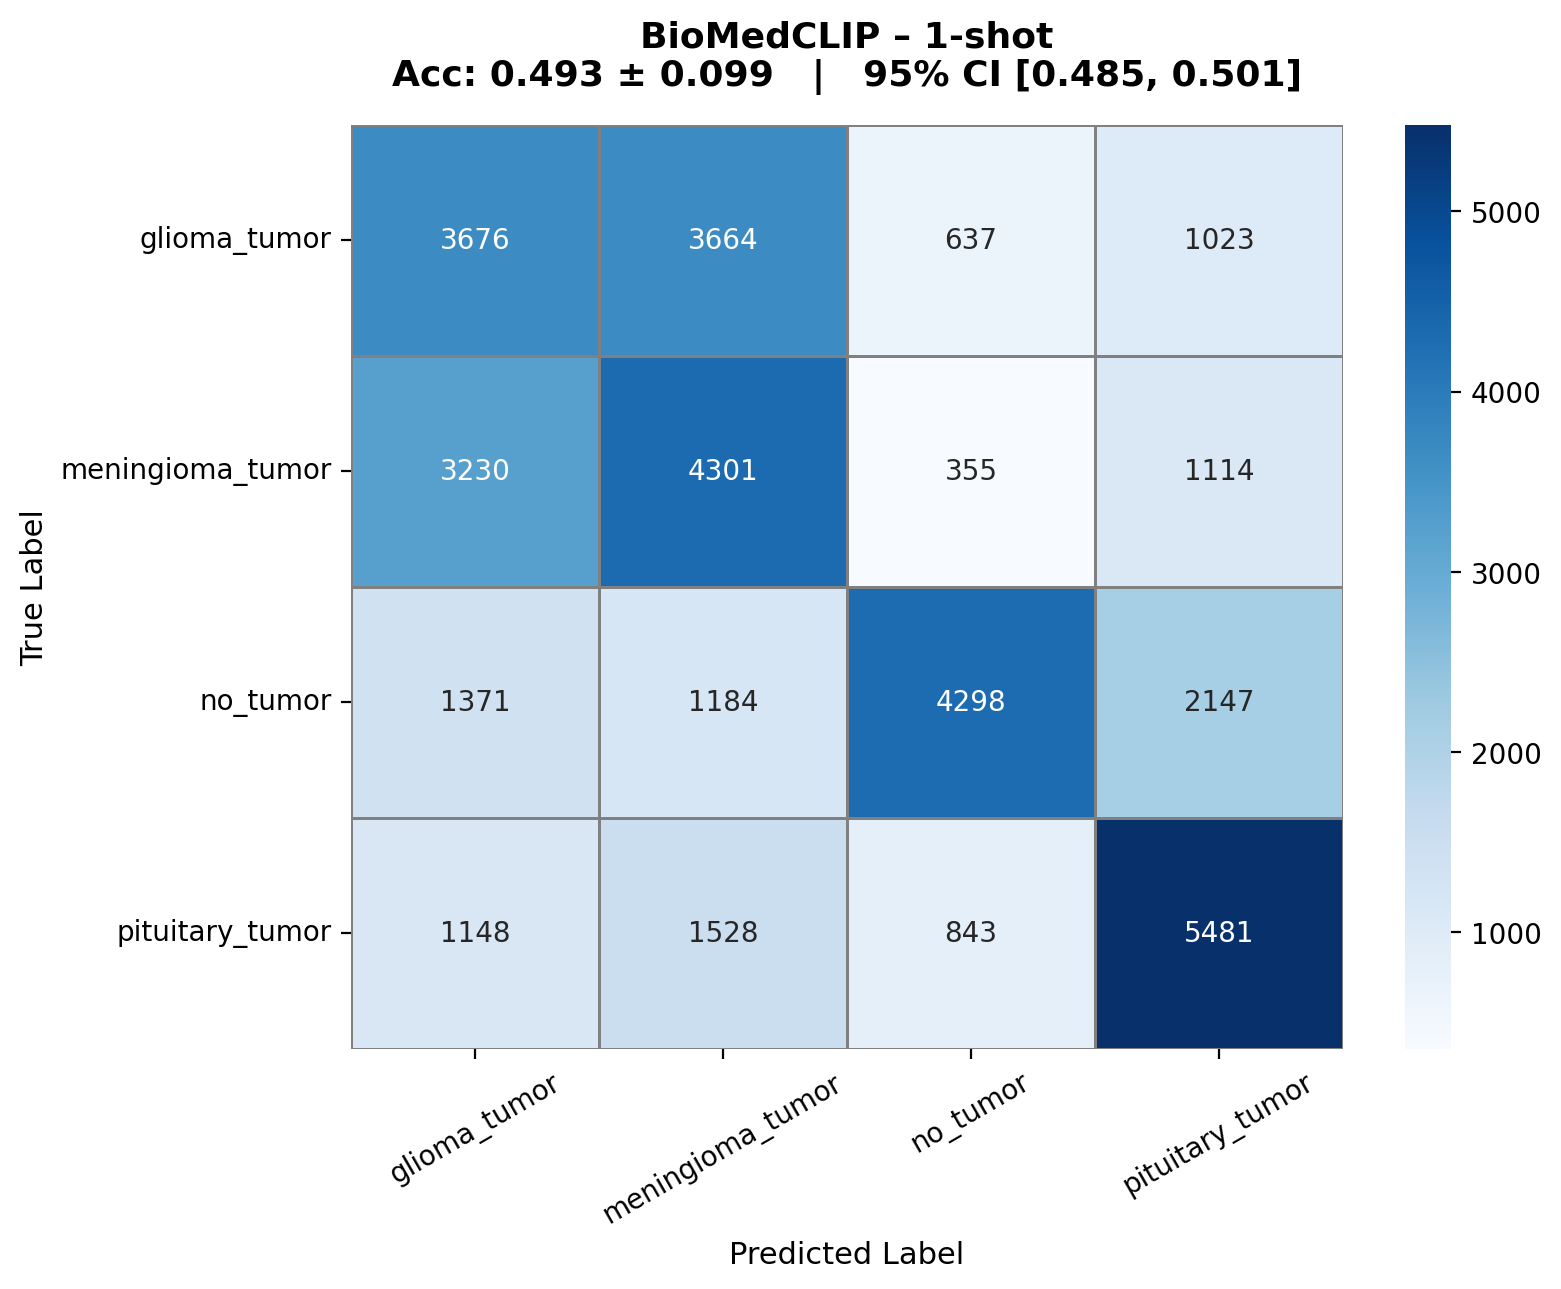

 ✓ Saved: /kaggle/working/cm_BioMedCLIP_1shot_pub.png

  1-SHOT | ResNet18  (Pure Prototypical )


1-shot ResNet18: 100%|██████████| 600/600 [00:00<00:00, 632.01it/s]



  Accuracy  : 0.3290 ± 0.0919
  95% CI    : [0.3218, 0.3362]
  Macro F1  : 0.3239 | Precision: 0.3233 | Recall: 0.3290

  Per-class metrics:
    glioma_tumor | P: 0.304 | R: 0.287 | F1: 0.295 | N: 9000
    meningioma_tumor | P: 0.254 | R: 0.227 | F1: 0.240 | N: 9000
    no_tumor     | P: 0.350 | R: 0.307 | F1: 0.327 | N: 9000
    pituitary_tumor | P: 0.386 | R: 0.494 | F1: 0.434 | N: 9000


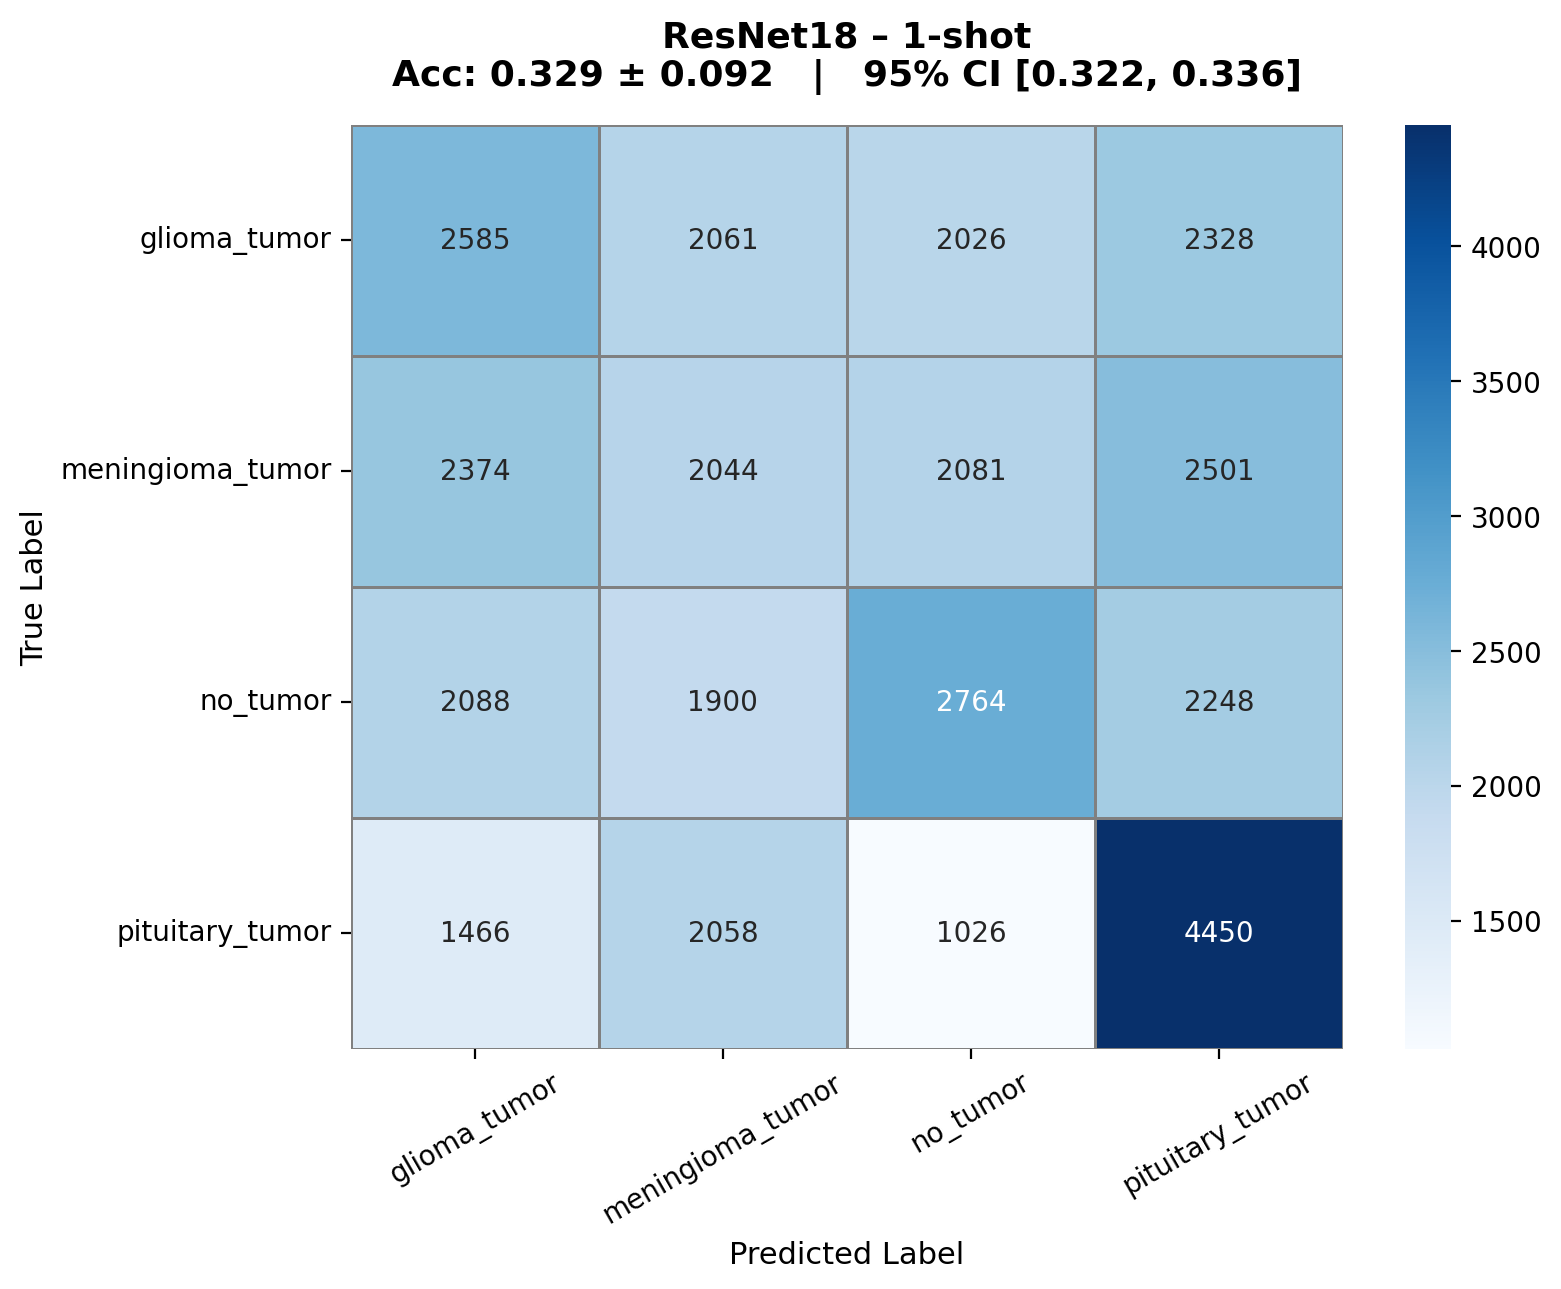

 ✓ Saved: /kaggle/working/cm_ResNet18_1shot_pub.png

  1-SHOT | EfficientNet-B0  (Pure Prototypical )


1-shot EfficientNet-B0: 100%|██████████| 600/600 [00:01<00:00, 596.84it/s]



  Accuracy  : 0.3304 ± 0.0885
  95% CI    : [0.3229, 0.3378]
  Macro F1  : 0.3249 | Precision: 0.3254 | Recall: 0.3304

  Per-class metrics:
    glioma_tumor | P: 0.296 | R: 0.265 | F1: 0.280 | N: 9000
    meningioma_tumor | P: 0.256 | R: 0.226 | F1: 0.240 | N: 9000
    no_tumor     | P: 0.380 | R: 0.335 | F1: 0.356 | N: 9000
    pituitary_tumor | P: 0.370 | R: 0.495 | F1: 0.424 | N: 9000


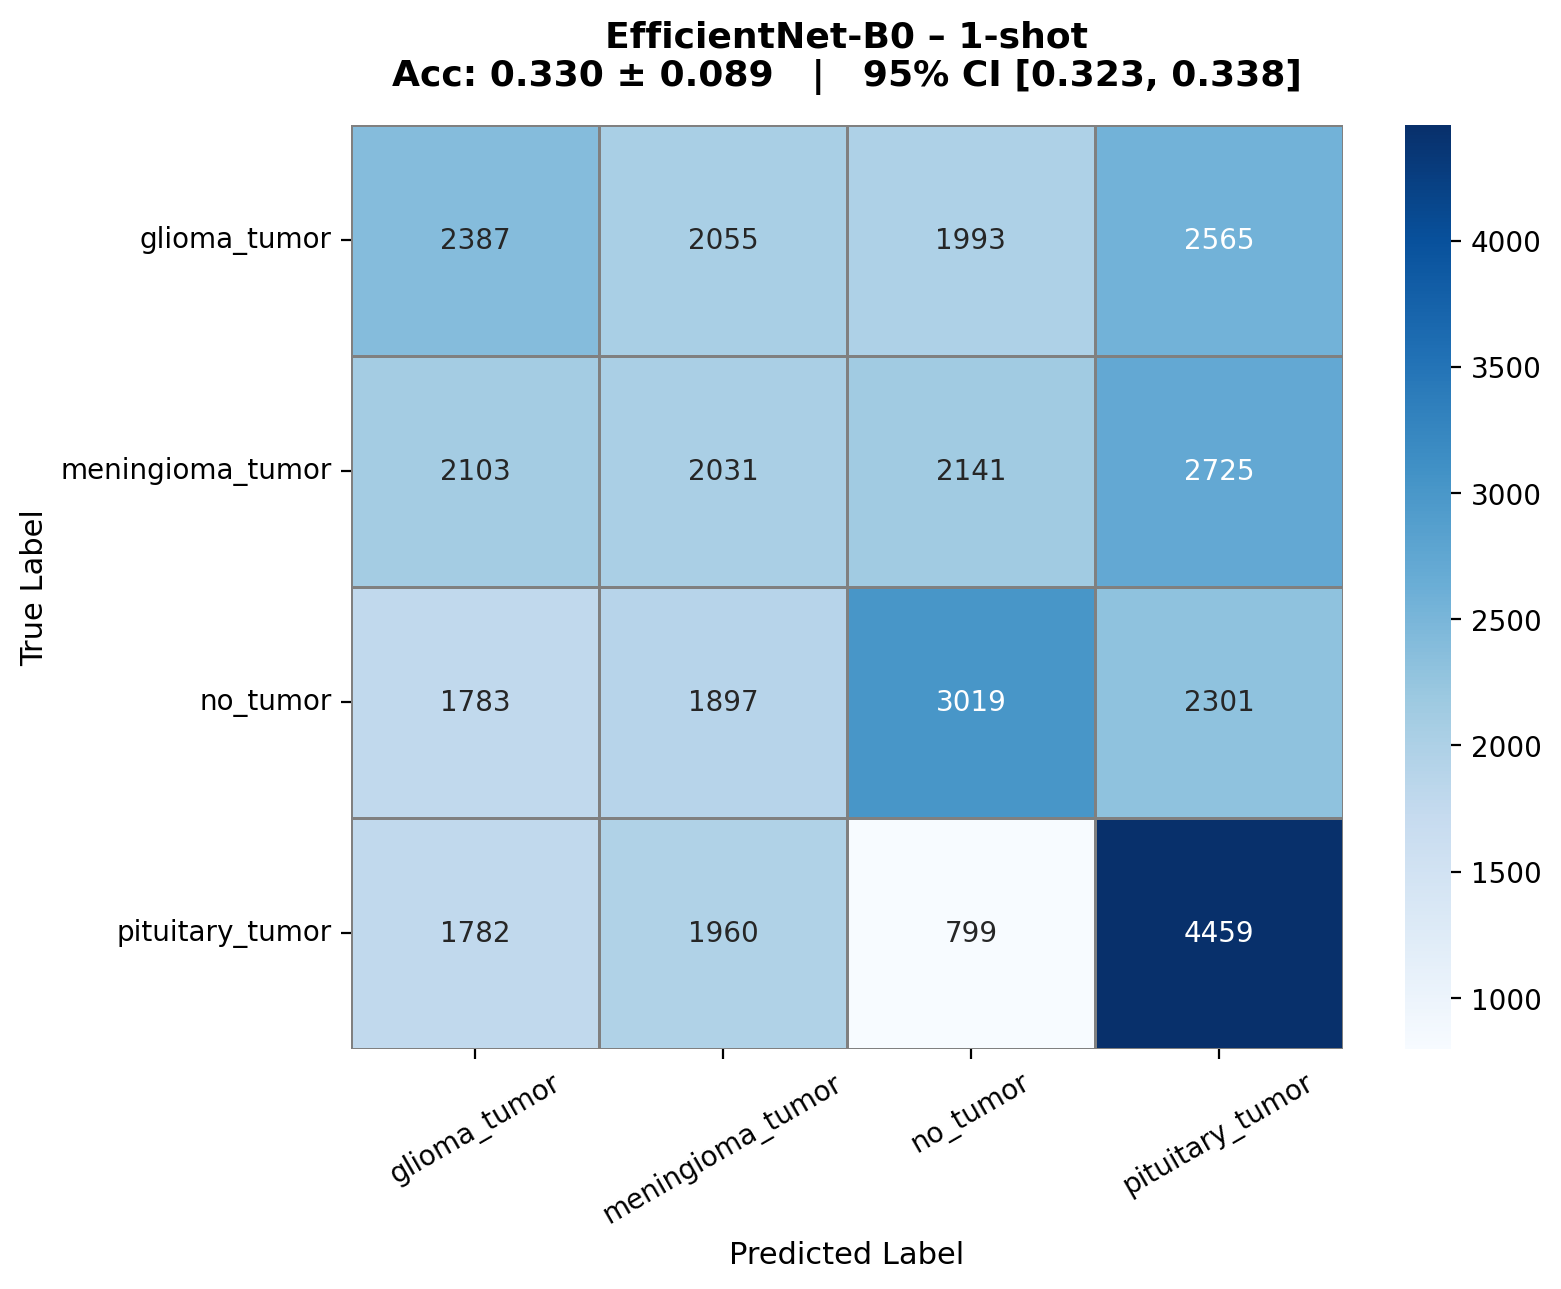

 ✓ Saved: /kaggle/working/cm_EfficientNet-B0_1shot_pub.png

  5-SHOT | BioMedCLIP  (Pure Prototypical )


5-shot BioMedCLIP: 100%|██████████| 600/600 [00:00<00:00, 628.03it/s]



  Accuracy  : 0.6188 ± 0.0665
  95% CI    : [0.6137, 0.6241]
  Macro F1  : 0.6165 | Precision: 0.6344 | Recall: 0.6188

  Per-class metrics:
    glioma_tumor | P: 0.498 | R: 0.466 | F1: 0.481 | N: 9000
    meningioma_tumor | P: 0.511 | R: 0.562 | F1: 0.535 | N: 9000
    no_tumor     | P: 0.854 | R: 0.580 | F1: 0.691 | N: 9000
    pituitary_tumor | P: 0.674 | R: 0.868 | F1: 0.758 | N: 9000


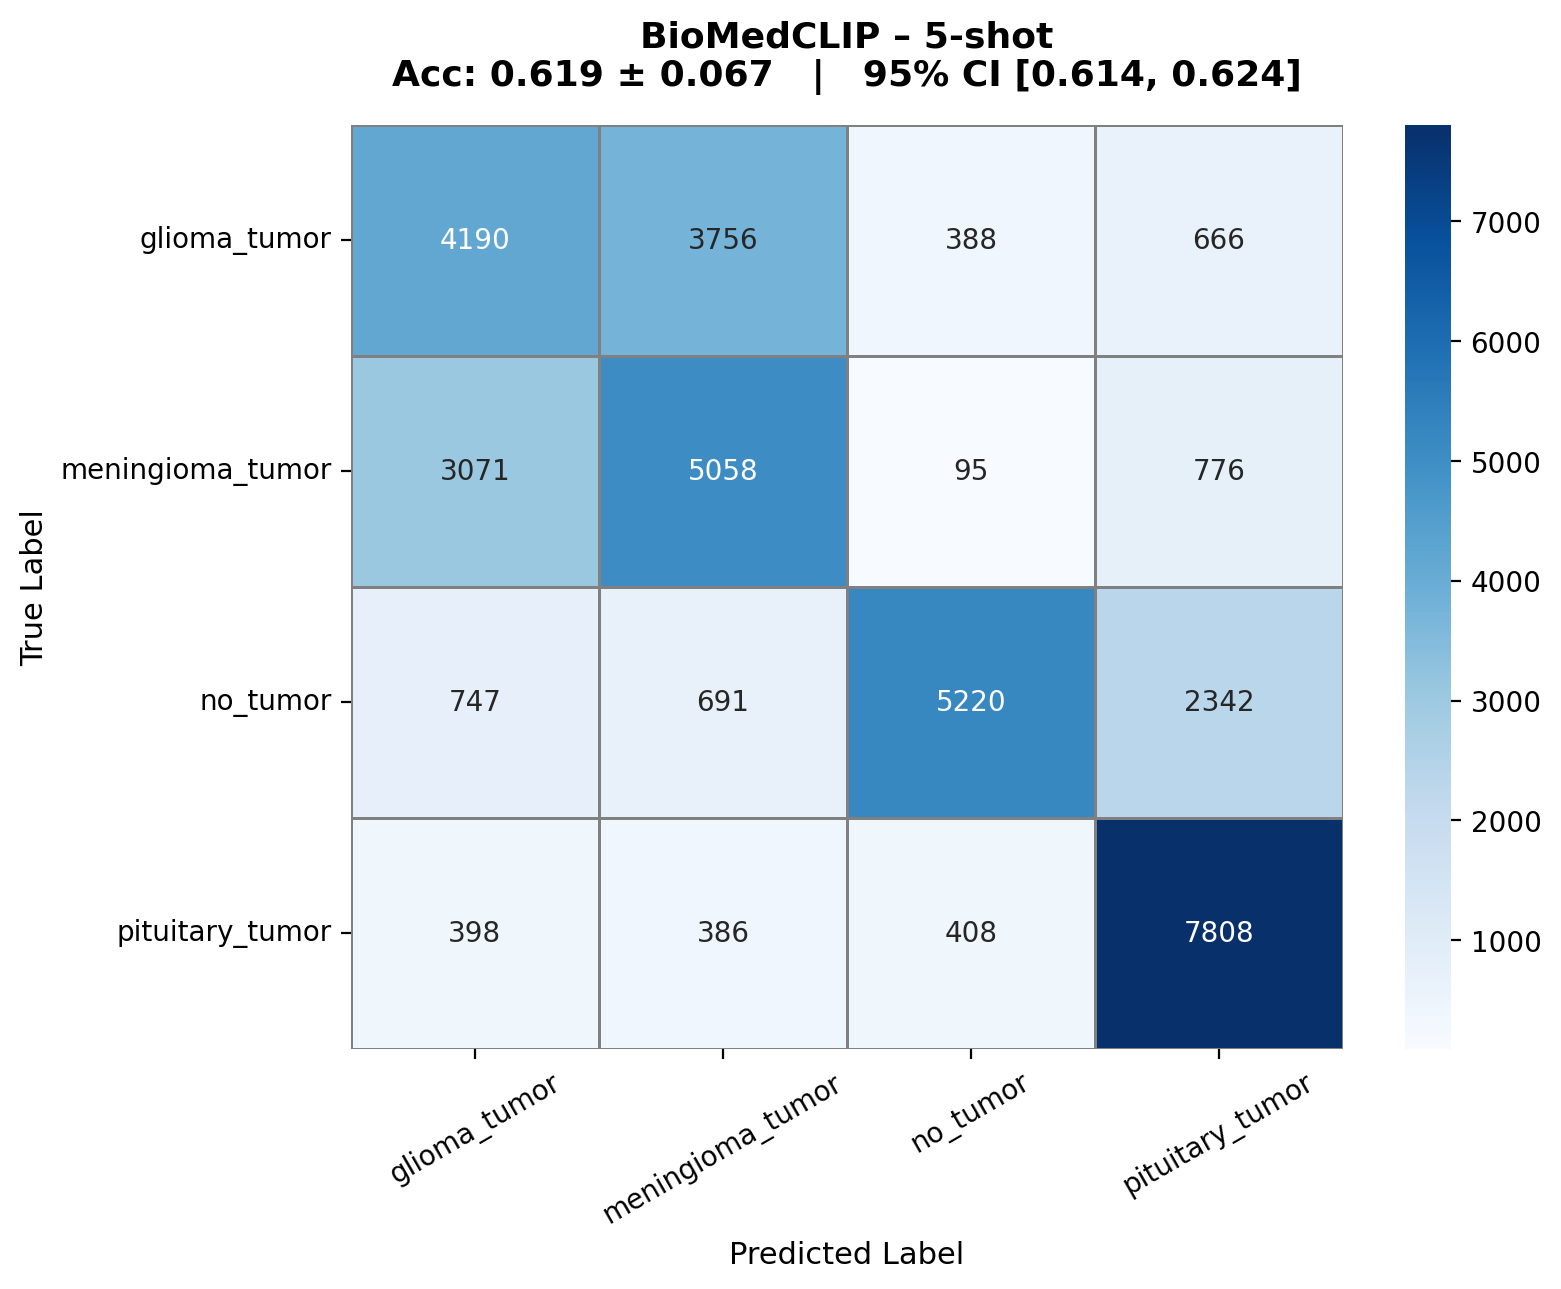

 ✓ Saved: /kaggle/working/cm_BioMedCLIP_5shot_pub.png

  5-SHOT | ResNet18  (Pure Prototypical )


5-shot ResNet18: 100%|██████████| 600/600 [00:00<00:00, 621.22it/s]



  Accuracy  : 0.4194 ± 0.0721
  95% CI    : [0.4137, 0.4256]
  Macro F1  : 0.3938 | Precision: 0.3976 | Recall: 0.4194

  Per-class metrics:
    glioma_tumor | P: 0.397 | R: 0.357 | F1: 0.376 | N: 9000
    meningioma_tumor | P: 0.285 | R: 0.176 | F1: 0.218 | N: 9000
    no_tumor     | P: 0.434 | R: 0.351 | F1: 0.388 | N: 9000
    pituitary_tumor | P: 0.474 | R: 0.794 | F1: 0.594 | N: 9000


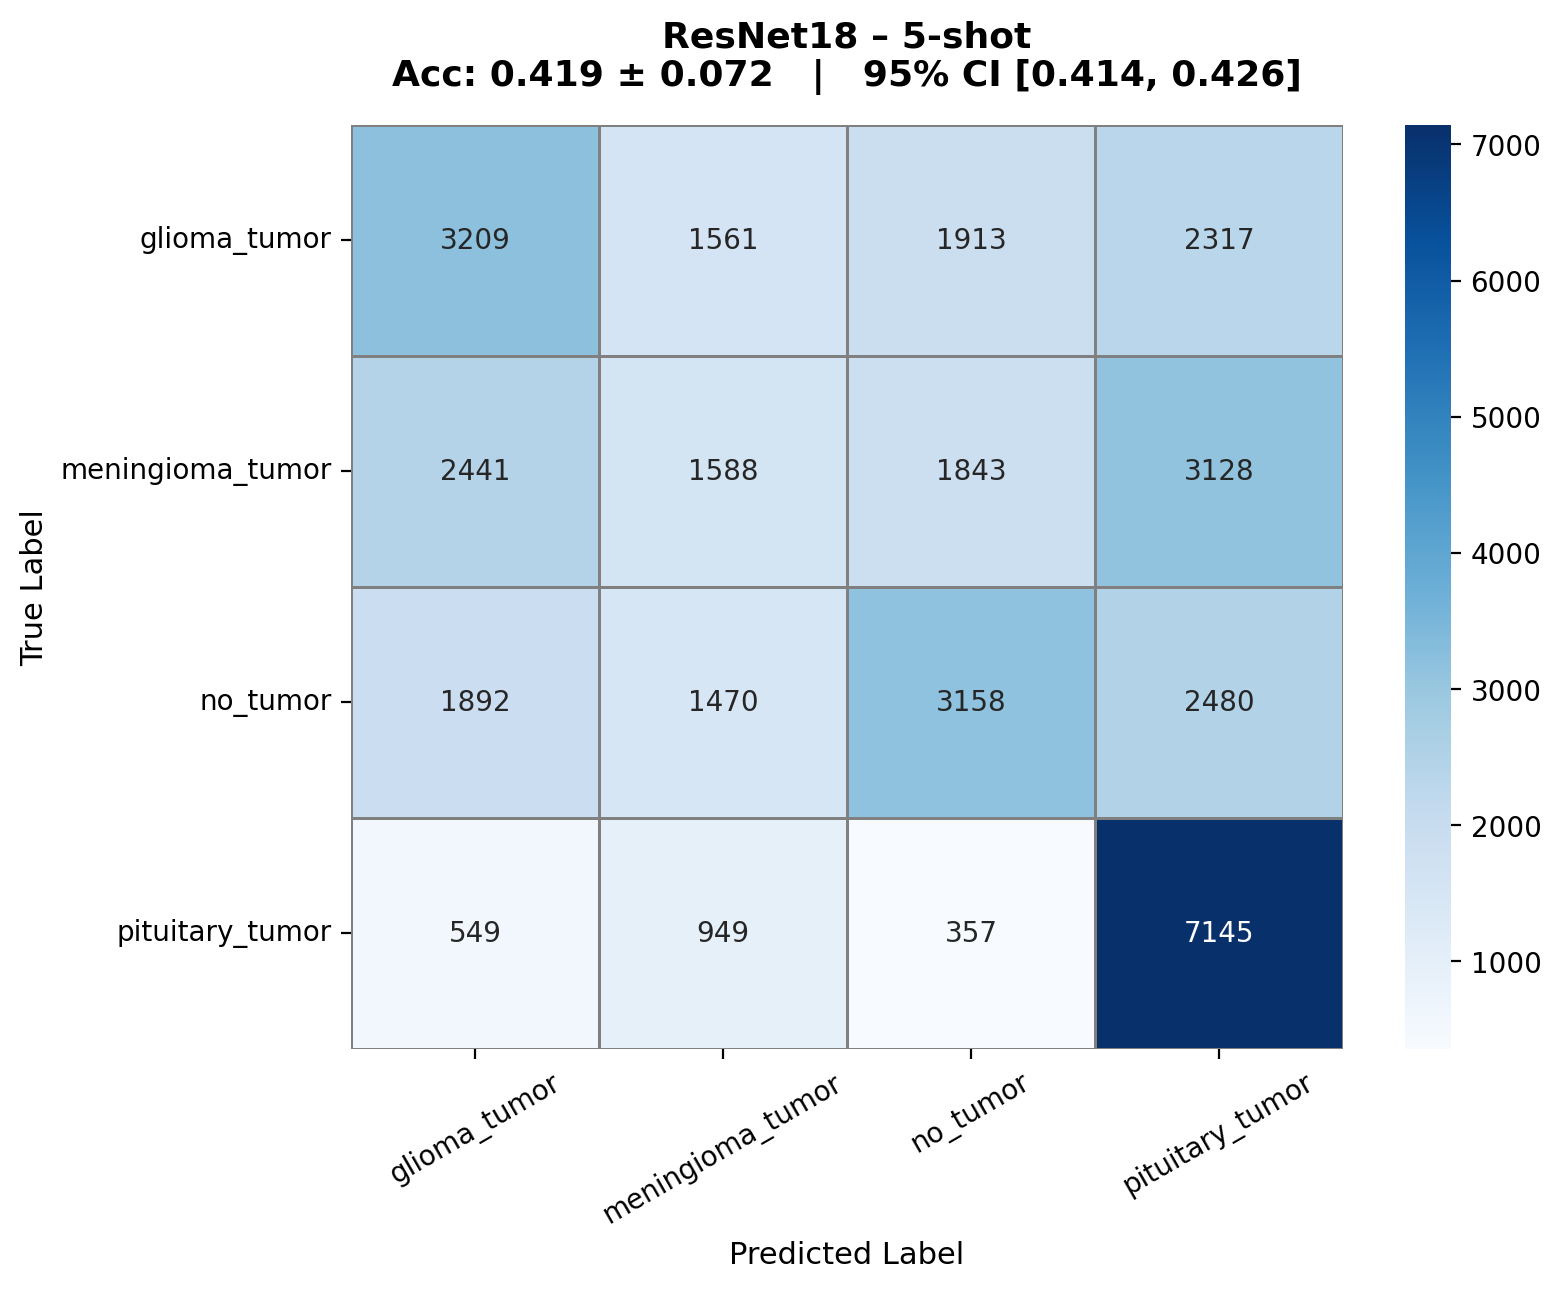

 ✓ Saved: /kaggle/working/cm_ResNet18_5shot_pub.png

  5-SHOT | EfficientNet-B0  (Pure Prototypical )


5-shot EfficientNet-B0: 100%|██████████| 600/600 [00:01<00:00, 583.85it/s]



  Accuracy  : 0.4065 ± 0.0704
  95% CI    : [0.4008, 0.4118]
  Macro F1  : 0.3752 | Precision: 0.3865 | Recall: 0.4065

  Per-class metrics:
    glioma_tumor | P: 0.370 | R: 0.288 | F1: 0.324 | N: 9000
    meningioma_tumor | P: 0.283 | R: 0.145 | F1: 0.192 | N: 9000
    no_tumor     | P: 0.463 | R: 0.395 | F1: 0.426 | N: 9000
    pituitary_tumor | P: 0.430 | R: 0.798 | F1: 0.559 | N: 9000


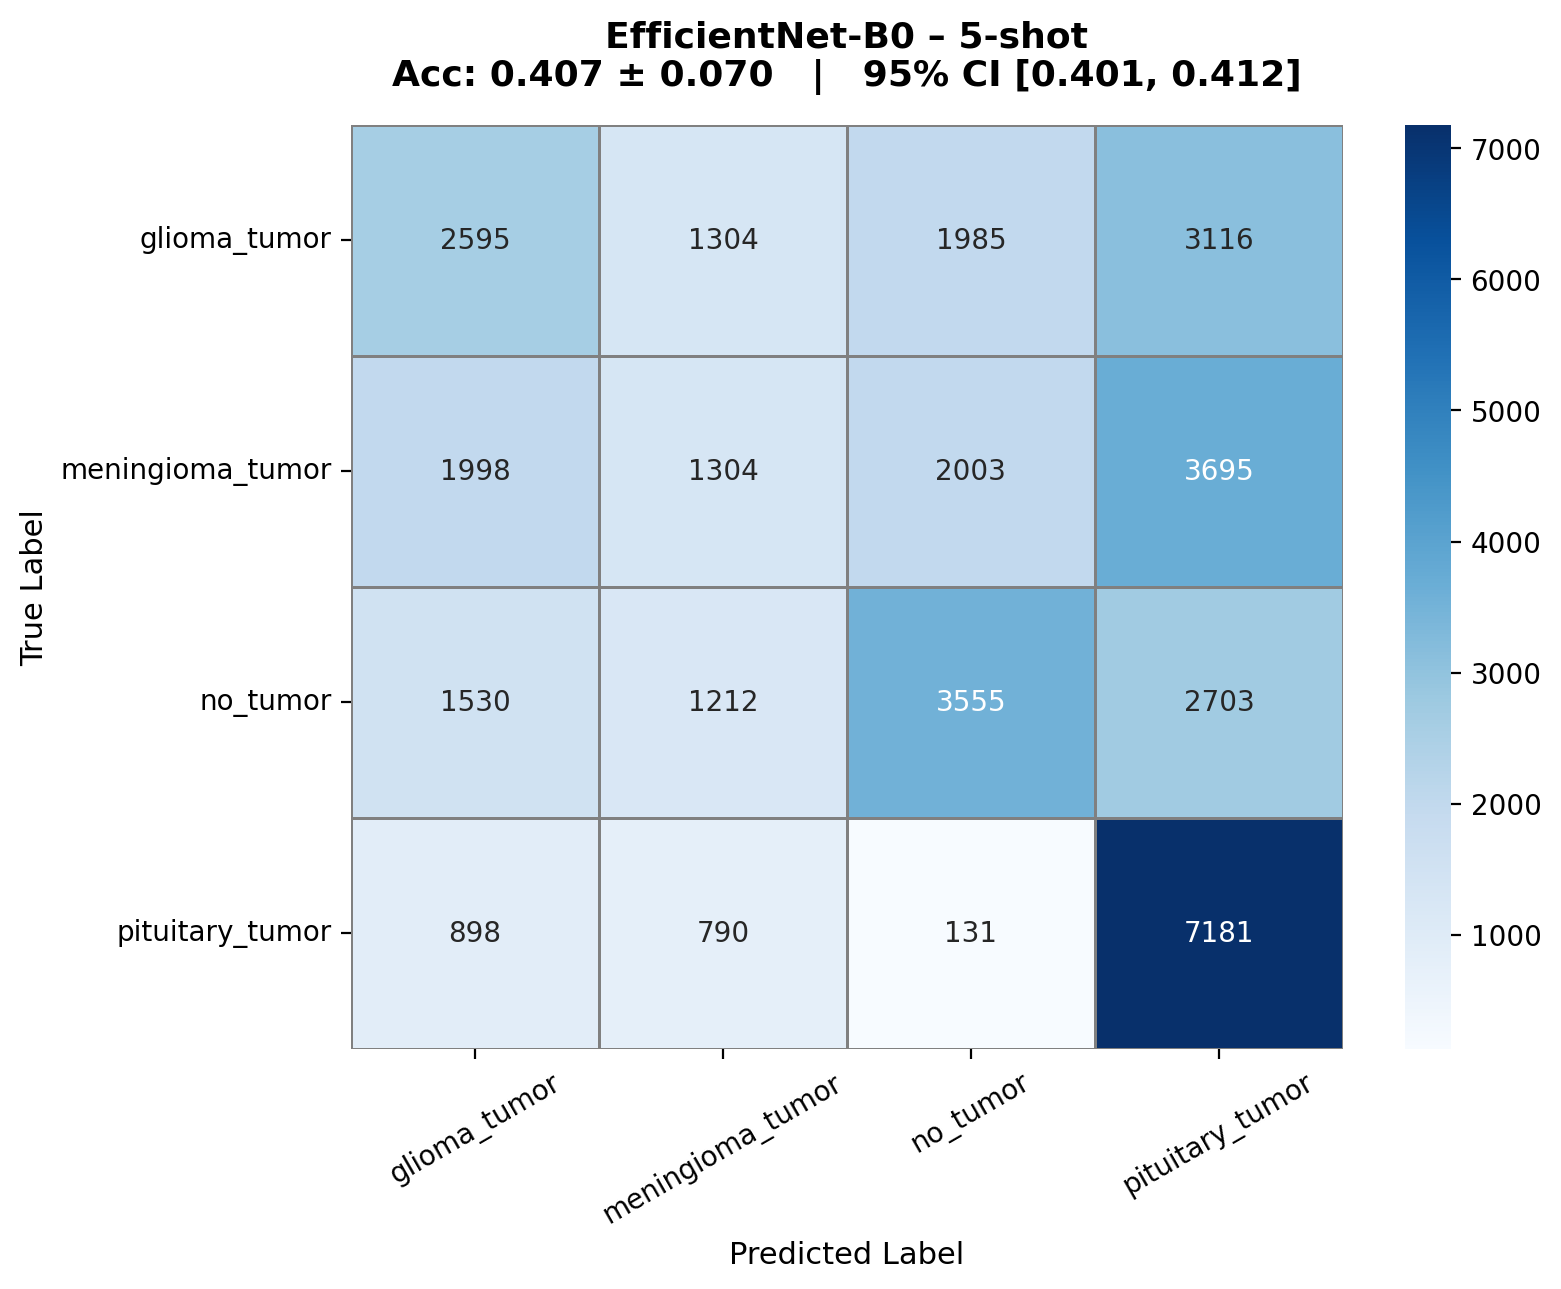

 ✓ Saved: /kaggle/working/cm_EfficientNet-B0_5shot_pub.png

  10-SHOT | BioMedCLIP  (Pure Prototypical )


10-shot BioMedCLIP: 100%|██████████| 600/600 [00:00<00:00, 611.63it/s]



  Accuracy  : 0.6507 ± 0.0525
  95% CI    : [0.6464, 0.6546]
  Macro F1  : 0.6463 | Precision: 0.6651 | Recall: 0.6507

  Per-class metrics:
    glioma_tumor | P: 0.557 | R: 0.488 | F1: 0.520 | N: 9000
    meningioma_tumor | P: 0.545 | R: 0.599 | F1: 0.571 | N: 9000
    no_tumor     | P: 0.873 | R: 0.598 | F1: 0.710 | N: 9000
    pituitary_tumor | P: 0.685 | R: 0.918 | F1: 0.785 | N: 9000


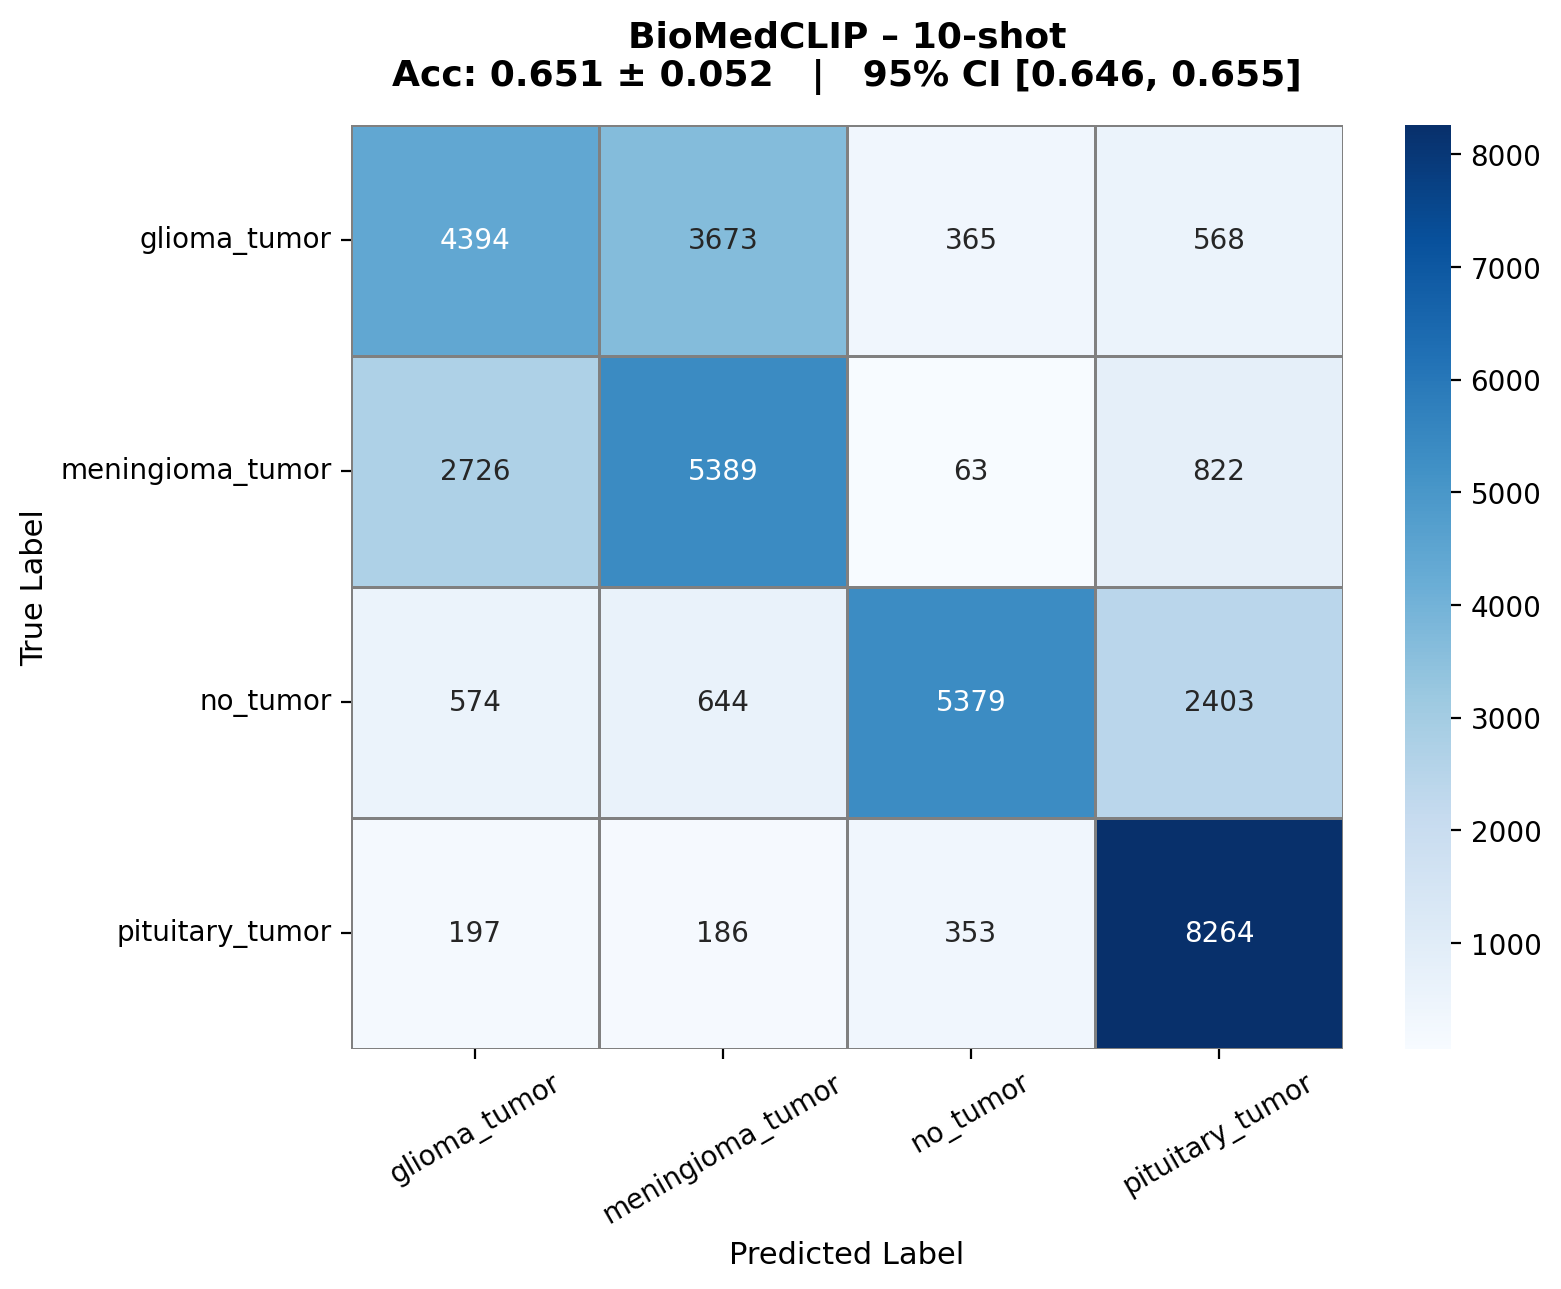

 ✓ Saved: /kaggle/working/cm_BioMedCLIP_10shot_pub.png

  10-SHOT | ResNet18  (Pure Prototypical )


10-shot ResNet18: 100%|██████████| 600/600 [00:01<00:00, 597.47it/s]



  Accuracy  : 0.4430 ± 0.0627
  95% CI    : [0.4378, 0.4482]
  Macro F1  : 0.4047 | Precision: 0.4157 | Recall: 0.4430

  Per-class metrics:
    glioma_tumor | P: 0.428 | R: 0.363 | F1: 0.393 | N: 9000
    meningioma_tumor | P: 0.303 | R: 0.135 | F1: 0.187 | N: 9000
    no_tumor     | P: 0.454 | R: 0.386 | F1: 0.417 | N: 9000
    pituitary_tumor | P: 0.479 | R: 0.888 | F1: 0.622 | N: 9000


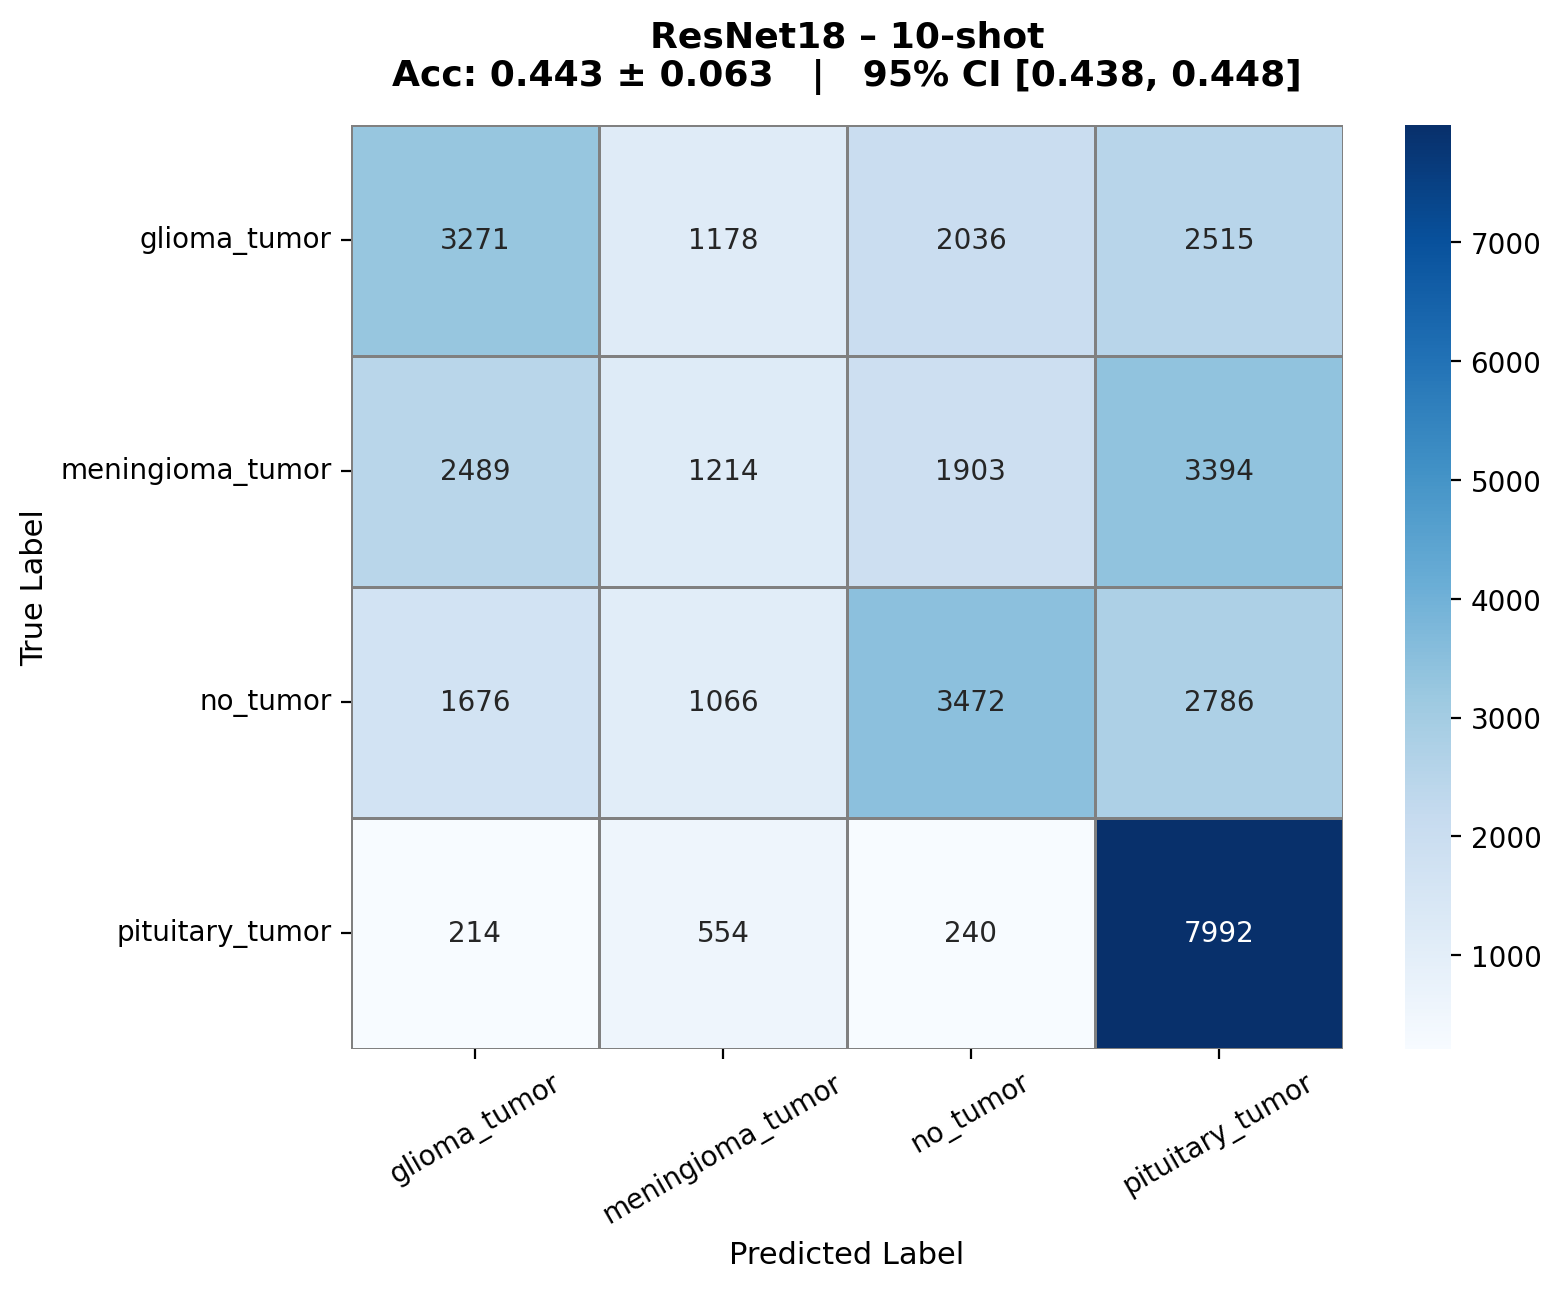

 ✓ Saved: /kaggle/working/cm_ResNet18_10shot_pub.png

  10-SHOT | EfficientNet-B0  (Pure Prototypical )


10-shot EfficientNet-B0: 100%|██████████| 600/600 [00:01<00:00, 545.31it/s]



  Accuracy  : 0.4272 ± 0.0587
  95% CI    : [0.4226, 0.4318]
  Macro F1  : 0.3827 | Precision: 0.4046 | Recall: 0.4272

  Per-class metrics:
    glioma_tumor | P: 0.409 | R: 0.295 | F1: 0.343 | N: 9000
    meningioma_tumor | P: 0.291 | R: 0.102 | F1: 0.151 | N: 9000
    no_tumor     | P: 0.488 | R: 0.435 | F1: 0.460 | N: 9000
    pituitary_tumor | P: 0.430 | R: 0.878 | F1: 0.578 | N: 9000


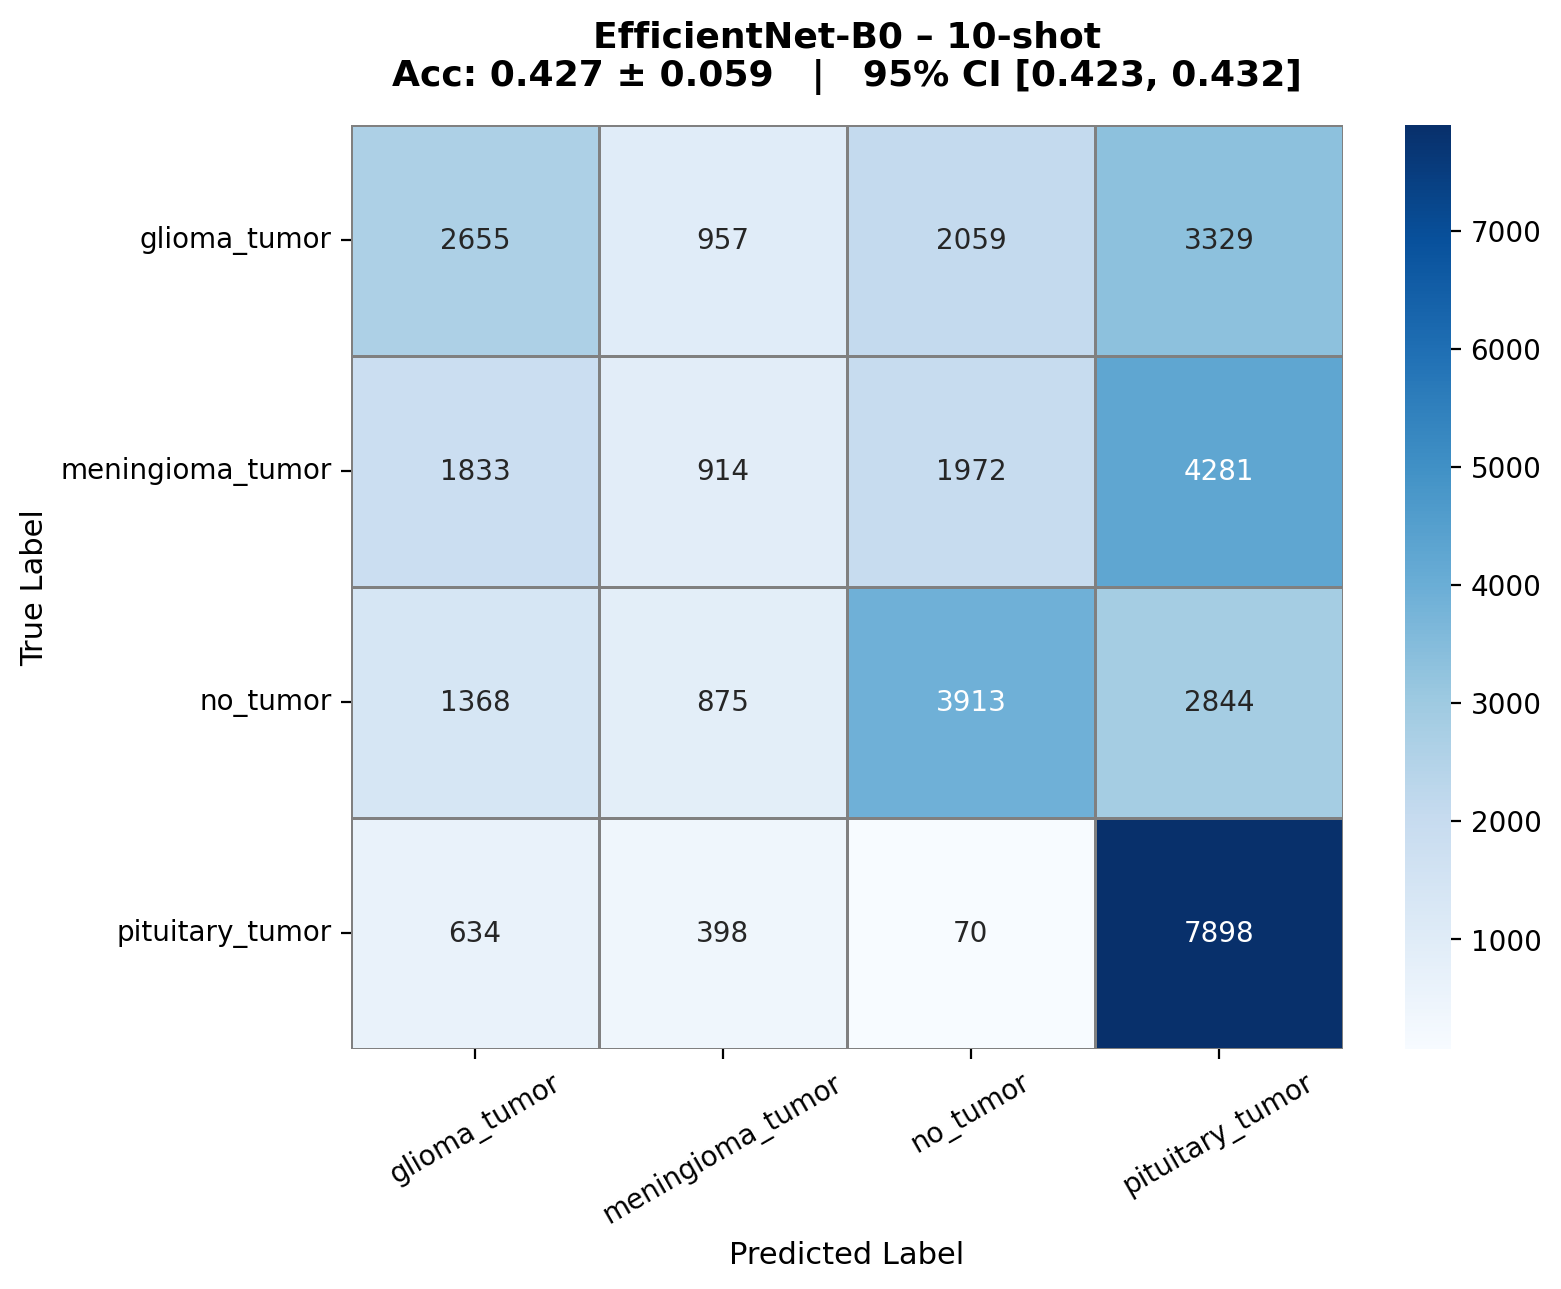

 ✓ Saved: /kaggle/working/cm_EfficientNet-B0_10shot_pub.png

##########################################################################################
 STATISTICAL SIGNIFICANCE (McNemar's Test)
##########################################################################################

 FINAL RESULTS SUMMARY


In [33]:
# ========================= RUN ALL EXPERIMENTS =========================
results = {}
print(f"\n{'#'*90}")
print(" FEW-SHOT EXPERIMENTS ( 600 Episodes)")
print(f"{'#'*90}\n")

for k in SHOTS:
    for name in model_configs:
        key = f"{name}_{k}shot"
        results[key] = run_fewshot(k_shot=k, name=name)

# McNemar tests 
print(f"\n{'#'*90}")
print(" STATISTICAL SIGNIFICANCE (McNemar's Test)")
print(f"{'#'*90}")
for k in SHOTS:
    model_names = list(model_configs.keys())
    for i in range(len(model_names)):
        for j in range(i+1, len(model_names)):
            ma, mb = model_names[i], model_names[j]
            ra = results[f"{ma}_{k}shot"]
            rb = results[f"{mb}_{k}shot"]
           

# Summary table 
print(f"\n{'='*90}")
print(f" FINAL RESULTS SUMMARY")
print(f"{'='*90}")



Generating summary visualizations...


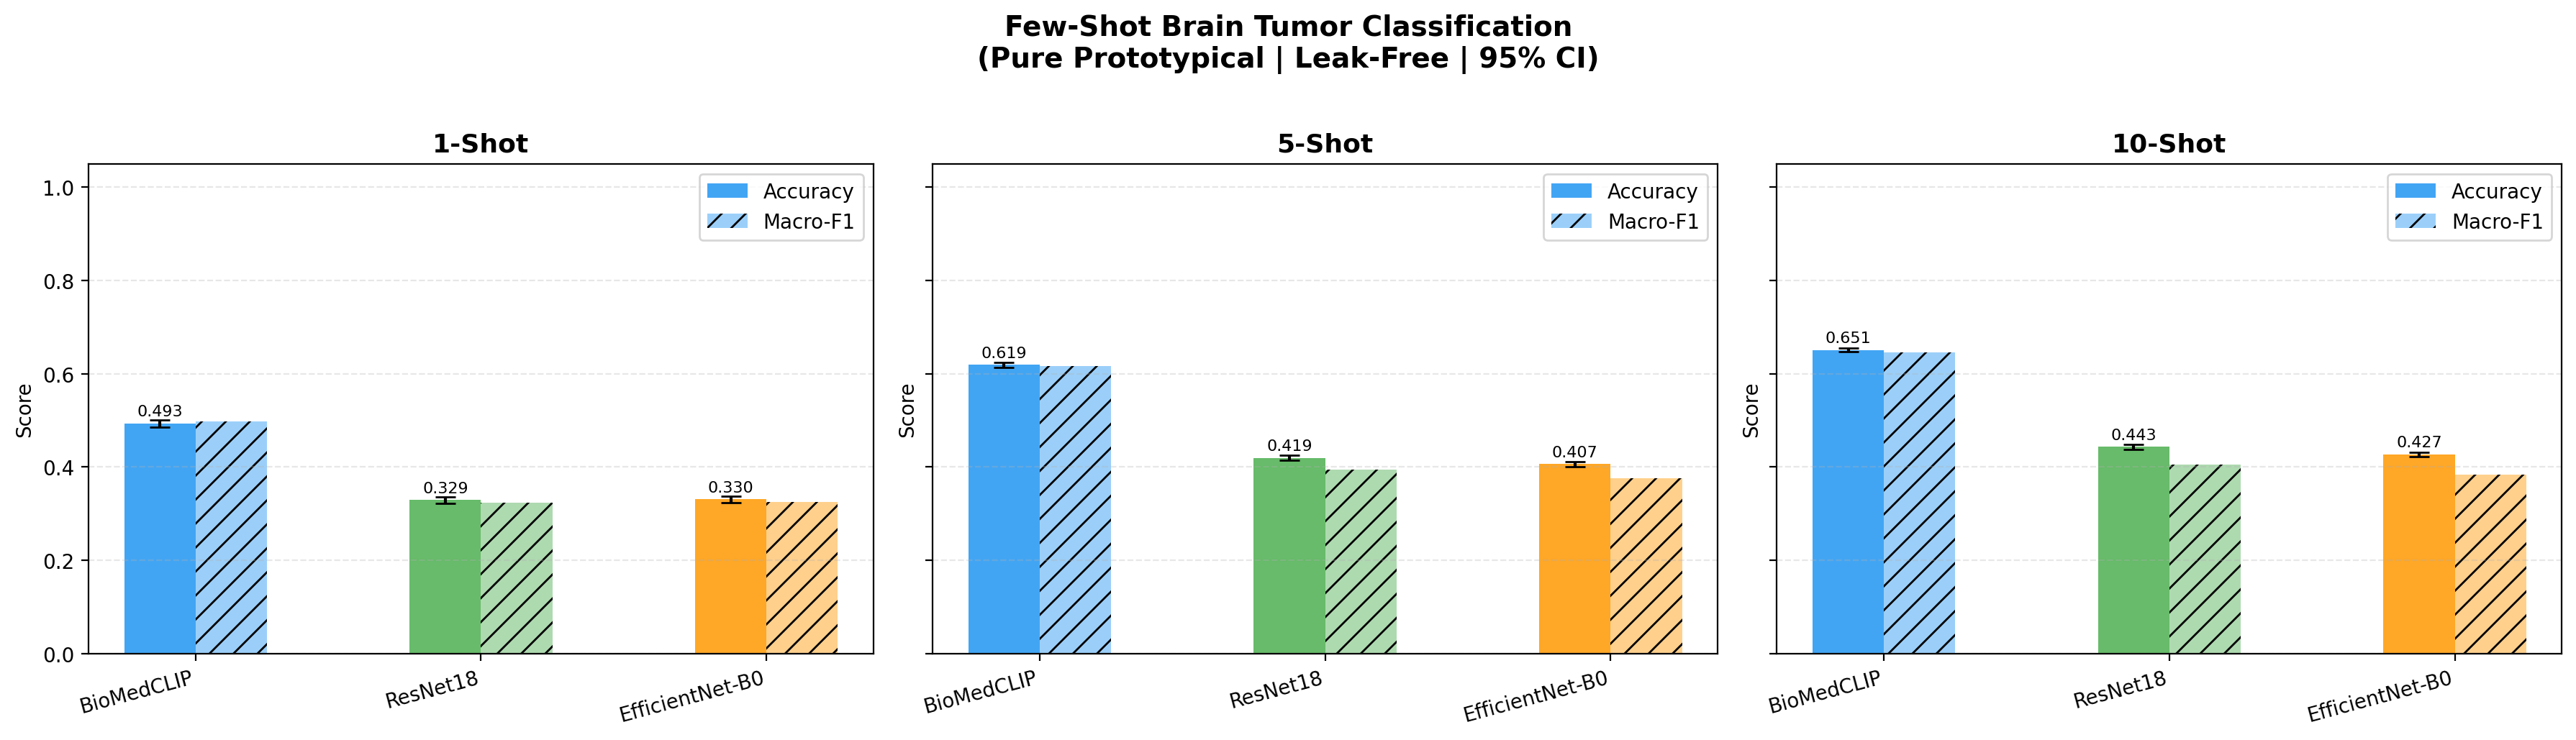

 ✓ Saved: /kaggle/working/summary_accuracy_f1.png


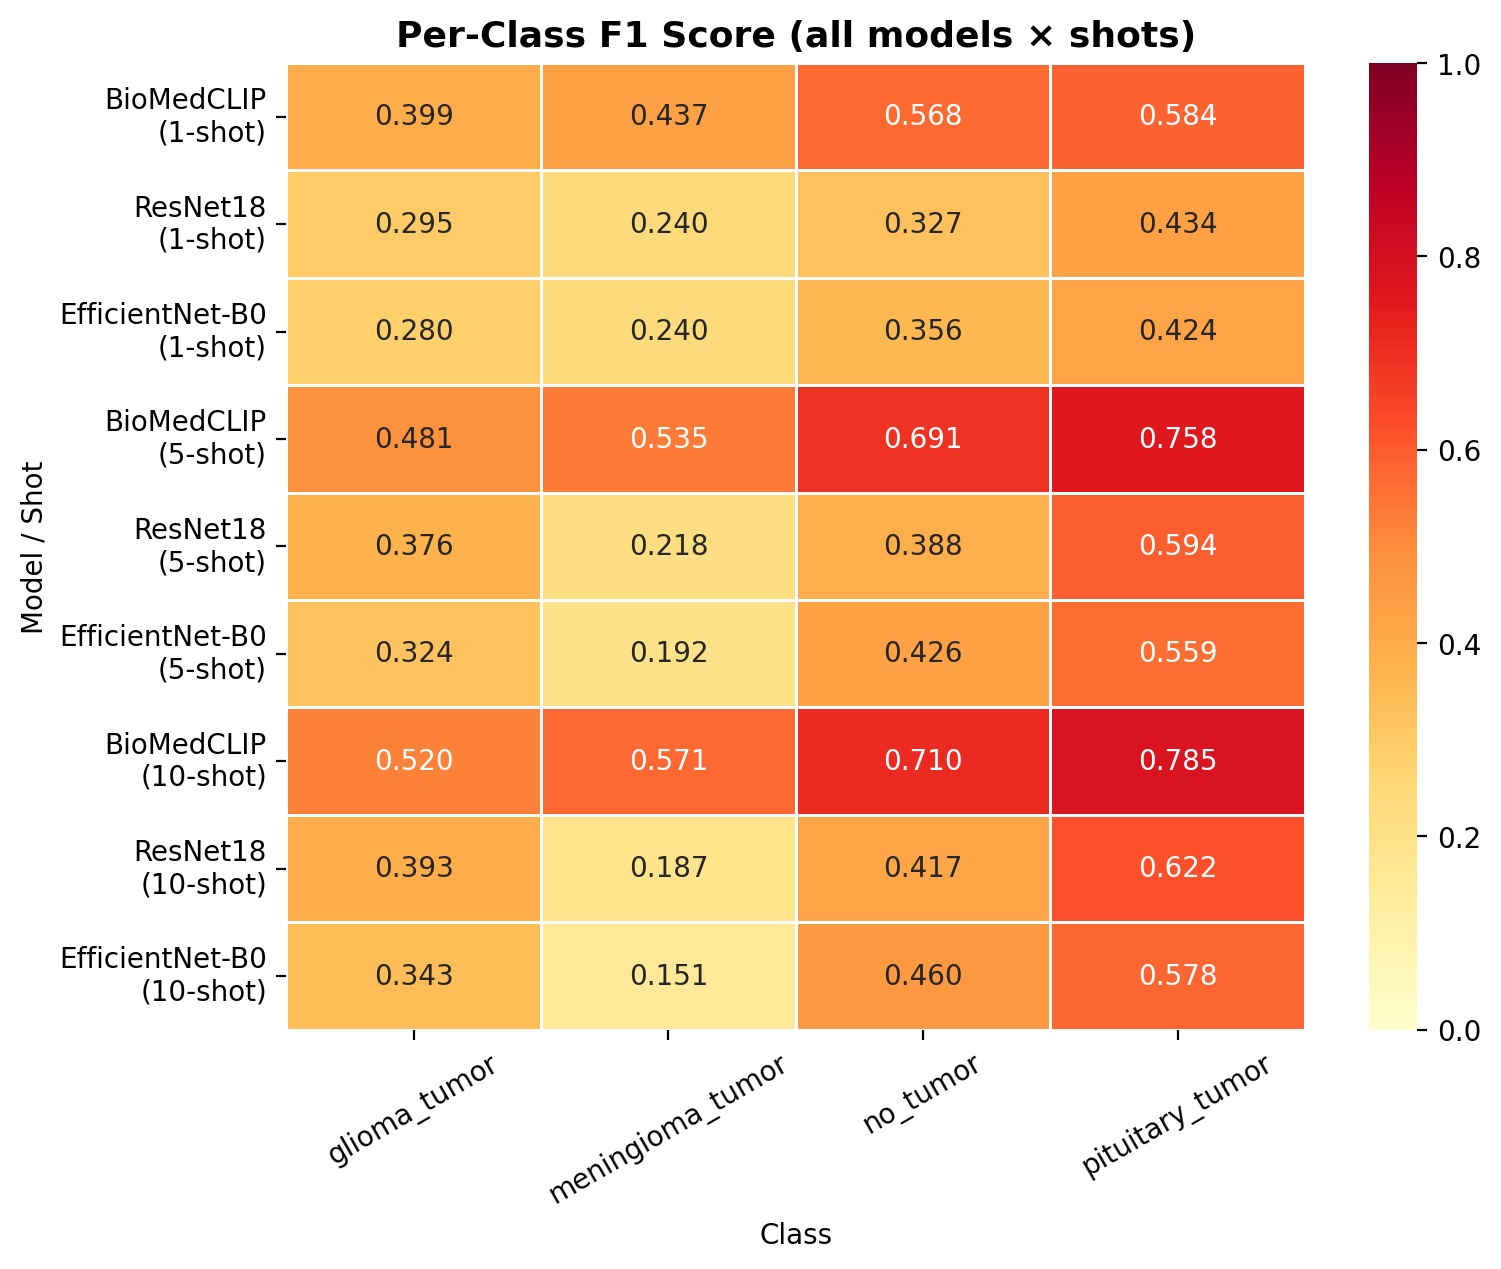

 ✓ Saved: /kaggle/working/perclass_f1_heatmap.png


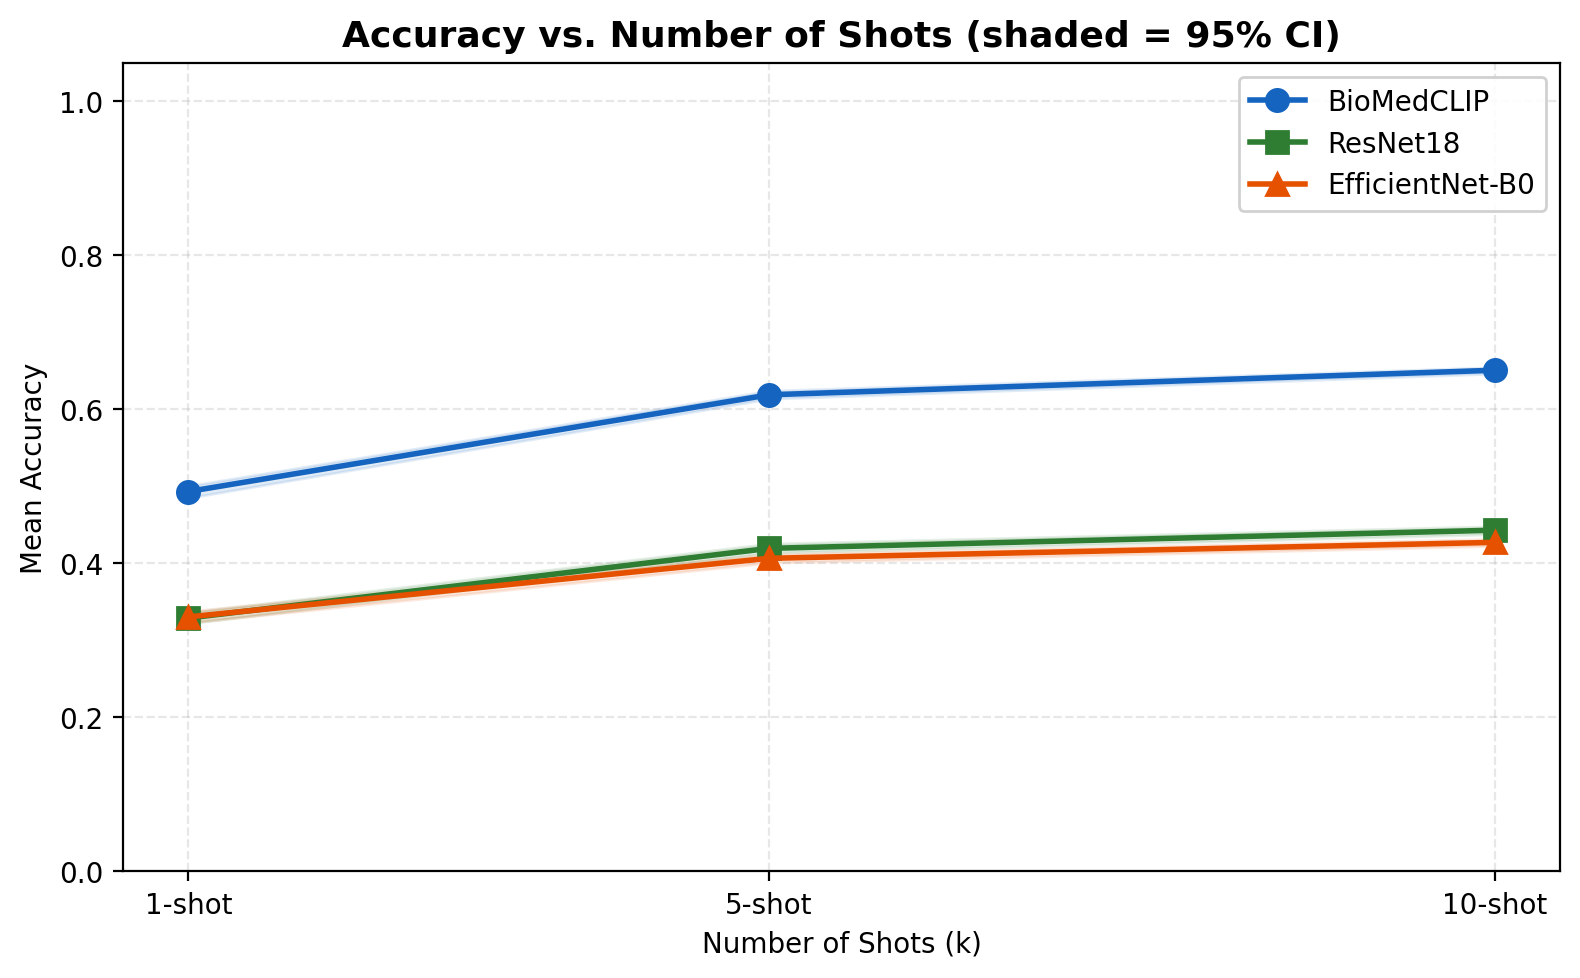

 ✓ Saved: /kaggle/working/shot_progression.png


In [34]:

# ========================= FINAL VISUALIZATIONS =========================
print("\nGenerating summary visualizations...")
plot_summary_chart(results, SHOTS, list(model_configs.keys()))
plot_perclass_heatmap(results, SHOTS, list(model_configs.keys()))
plot_shot_progression(results, SHOTS, list(model_configs.keys()))

